1.- Descarga precios históricos de tres activos financieros distintos El periodo de análisis debe cubrir al menos 3 años.

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import yfinance as yf

In [47]:
tickers = ["AAPL", "MSFT", "GOOGL"]
prices = yf.download(tickers, start = '2021-01-01', end = '2026-03-01')['Close']
prices

[*********************100%***********************]  3 of 3 completed


Ticker,AAPL,GOOGL,MSFT
Date,,,
2021-01-04,125.856697,85.659286,208.406525
2021-01-05,127.412727,86.350067,208.607605
2021-01-06,123.123863,85.498001,203.198532
2021-01-07,127.325226,88.051704,208.980942
2021-01-08,128.424225,89.217400,210.254242
...,...,...,...
2026-02-23,266.179993,311.489990,384.470001
2026-02-24,272.140015,310.899994,389.000000
2026-02-25,274.230011,312.899994,400.600006


2.- Calcula los rendimientos diarios y estima sus medias y matriz de covarianzas.

In [48]:
rets = precios.pct_change().dropna()
rets

Ticker,AAPL,GOOGL,MSFT
Date,,,
2021-01-05,0.012364,0.008064,0.000965
2021-01-06,-0.033661,-0.009868,-0.025929
2021-01-07,0.034123,0.029869,0.028457
2021-01-08,0.008631,0.013239,0.006093
2021-01-11,-0.023249,-0.023106,-0.009699
...,...,...,...
2026-02-23,0.006047,-0.011080,-0.032122
2026-02-24,0.022391,-0.001894,0.011782
2026-02-25,0.007680,0.006433,0.029820


In [49]:
mean = retornos.mean()
mean

Ticker
AAPL     0.000727
GOOGL    0.001189
MSFT     0.000626
dtype: float64

In [50]:
cov = retornos.cov()
cov

Ticker,AAPL,GOOGL,MSFT
Ticker,,,
AAPL,0.000308,0.000195,0.000175
GOOGL,0.000195,0.000379,0.000198
MSFT,0.000175,0.000198,0.000272


In [51]:
mean_annual = medias_diarias * 252
cov_annual = covarianza_diaria * 252

3.- Simula al menos 10,000 portafolios conformados por los tres activos, con pesos aleatorios que sumen 1.

4.- Para cada portafolio, calcula:

- Rendimiento esperado.

- Riesgo (desviación estándar).

- Ratio de Sharpe (considera una tasa libre de riesgo de 4% anual).

In [59]:
n_assets = len(tickers)
num_portfolios = 10000
rf_annual = 0.04

results = np.zeros((num_portfolios, 3)) 
weights_store = np.zeros((num_portfolios, n_assets))

for i in range(num_portfolios):
    # Pesos aleatorios que suman 1
    w = np.random.random(n_assets)
    w = w / np.sum(w)
    # retorno esperado anual del portafolio
    port_return = np.dot(w, mean_annual)
    # riesgo
    port_var = np.dot(w.T, np.dot(cov_annual, w))
    port_risk = np.sqrt(port_var)
    # Sharpe anual 
    sharpe = (port_return - rf_annual) / port_risk if port_risk != 0 else np.nan
    results[i, 0] = port_return
    results[i, 1] = port_risk
    results[i, 2] = sharpe
    weights_store[i, :] = w

In [60]:
# Convertimos a DataFrame
cols = ["Return", "Risk", "Sharpe"]
df = pd.DataFrame(results, columns=cols)

for j, t in enumerate(tickers):
    df[f"W_{t}"] = weights_store[:, j]


In [54]:
min_risk = df["Risk"].idxmin()
max_return = df["Return"].idxmax()
max_sharpe = df["Sharpe"].idxmax()

In [55]:
min_risk_port = df.loc[min_risk]
max_return_port = df.loc[max_return]
max_sharpe_port = df.loc[max_sharpe]

In [56]:
print("=== Portafolio de MENOR RIESGO ===")
print(min_risk_port, "\n")

print("=== Portafolio de MAYOR RENDIMIENTO ===")
print(max_return_port, "\n")

print("=== Portafolio de MAYOR SHARPE ===")
print(max_sharpe_port, "\n")

=== Portafolio de MENOR RIESGO ===
Return     0.189342
Risk       0.238512
Sharpe     0.626138
W_AAPL     0.356500
W_MSFT     0.158734
W_GOOGL    0.484766
Name: 1575, dtype: float64 

=== Portafolio de MAYOR RENDIMIENTO ===
Return     0.299406
Risk       0.308948
Sharpe     0.839641
W_AAPL     0.001486
W_MSFT     0.998415
W_GOOGL    0.000099
Name: 7029, dtype: float64 

=== Portafolio de MAYOR SHARPE ===
Return     0.292478
Risk       0.300327
Sharpe     0.840675
W_AAPL     0.060416
W_MSFT     0.939016
W_GOOGL    0.000568
Name: 1851, dtype: float64 



5.- Grafica el diagrama riesgo–rendimiento con todos los portafolios. En la misma figura:

- Identifica el portafolio de menor riesgo.

- Identifica el portafolio de mayor rendimiento.

- Identifica el portafolio con mayor Sharpe.

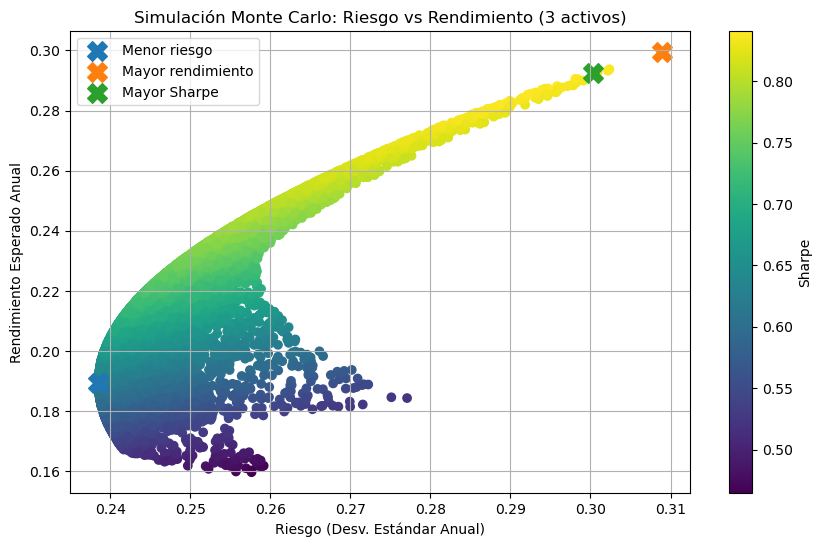

In [57]:
plt.figure(figsize=(10, 6))
sc = plt.scatter(df["Risk"], df["Return"], c=df["Sharpe"])
plt.colorbar(sc, label="Sharpe")
plt.scatter(min_risk_port["Risk"], min_risk_port["Return"], marker="X", s=200, label="Menor riesgo")
plt.scatter(max_return_port["Risk"], max_return_port["Return"], marker="X", s=200, label="Mayor rendimiento")
plt.scatter(max_sharpe_port["Risk"], max_sharpe_port["Return"], marker="X", s=200, label="Mayor Sharpe")
plt.title("Simulación Monte Carlo: Riesgo vs Rendimiento (3 activos)")
plt.xlabel("Riesgo (Desv. Estándar Anual)")
plt.ylabel("Rendimiento Esperado Anual")
plt.legend()
plt.grid(True)
plt.show()

## Análisis

A partir de la simulación Monte Carlo con 10,000 portafolios, se identificaron tres diferentes portafolios: el portafolio de menor riesgo, el de mayor rendimiento y el de mayor ratio de Sharpe. El portafolio de menor riesgo presenta una desviación estándar anual aproximada de 23.85% y un rendimiento esperado cercano a 18.93%. Este portafolio es adecuado para inversionistas con perfil conservador, ya que prioriza estabilidad sobre rentabilidad máxima. El portafolio de mayor rendimiento alcanza un retorno esperado cercano a 29.94%, pero con un riesgo considerablemente más alto (30.89%). Aunque ofrece el mayor potencial de ganancia, también implica mayor volatilidad, por lo que es más apropiado para inversionistas con alta tolerancia al riesgo. El portafolio de mayor Sharpe presenta un rendimiento esperado de aproximadamente 29.24% con un riesgo de 30.03%, obteniendo el mejor balance entre retorno y riesgo (Sharpe = 0.8406). Este portafolio maximiza la rentabilidad por unidad de riesgo asumido. Con base en los resultados, recomendaría el portafolio de mayor ratio de Sharpe, ya que optimiza la relación riesgo–rendimiento. Aunque su nivel de riesgo es mayor que el portafolio de mínima volatilidad, ofrece una compensación más eficiente por cada unidad de riesgo asumido, lo que lo convierte en la alternativa más racional desde una perspectiva de optimización financiera. En conclusión, si el objetivo es maximizar la eficiencia del portafolio bajo un enfoque moderno de teoría de portafolios, la mejor elección es el portafolio con mayor Sharpe.